In [1]:
# -*- coding: utf-8 -*-
"""
Created on 2025-01-01
Revised on 2026-04-03

@author:       Oscar Trevizo
@institution:  Harvard Extension School — Graduate Data Science Program (2023)
@context:      Independent project — applying course concepts to real-world data
@environment:  Python 3.14.3 | myenv | MacBook Air M5

Boosting Regression — OJ Dataset (ISLR Ch. 8)
==============================================

Description:
    Demonstrates gradient boosting regression using the OJ dataset from the
    ISLR/ISLP library. Predicts SalePriceMM (sale price of Minute Maid OJ)
    using PriceDiff, PctDiscMM, and SalePriceCH as predictors.

    Note: Unlike notebook #5 (Random Forest), PriceDiff IS included here
    as a predictor — this is intentional in the original R script.

    Mirrors R: caret::train(method='xgbTree') with a fixed tuneGrid
    of XGBoost hyperparameters (nrounds=500, max_depth=3, eta=0.2,
    gamma=2.1, colsample_bytree=1, min_child_weight=1, subsample=1).

    Python implementation uses sklearn GradientBoostingRegressor as the
    primary model (always available in myenv), with a note on xgboost
    as a direct alternative. Hyperparameters are mapped as closely as
    possible to the R xgbTree specification.

    Covers:
      - Data loading and preparation
      - Train/test split
      - Boosting fit with cross-validation (RepeatedKFold)
      - Hyperparameter grid search (mirrors caret tuneGrid)
      - Feature importances (mirrors varImp)
      - Predictions on test set
      - Scatter plot: actuals vs predictions
      - RMSE and R-squared
      - Comparison of boosting vs random forest (notebooks #5 and #6)

    R equivalent: boosting_train_caret_regression_ISLR_OJ.Rmd
    R libraries:  caret (train/trainControl, xgbTree), ISLR, ggplot2
    Python libs:  ISLP, numpy, pandas, matplotlib, seaborn, sklearn

Dataset:
    OJ {ISLR/ISLP} — Orange Juice purchase data
    1070 observations, 18 variables
    Response variable: SalePriceMM (Sale Price of Minute Maid OJ, USD)
    Predictors: PriceDiff, PctDiscMM, SalePriceCH

Revision History:
    2025-01-01  Original R development (Harvard STAT 109, 2023)
                - R script: boosting_train_caret_regression_ISLR_OJ.Rmd
                - Uses caret::train(method='xgbTree')

    2026-04-03  Converted to Python / Jupyter Notebook
                - caret::train(method='xgbTree') → sklearn.GradientBoostingRegressor
                - trainControl(repeatedcv) → RepeatedKFold + GridSearchCV
                - xgbTree hyperparams mapped to sklearn equivalents
                - varImp(boo) → feature_importances_ bar chart
                - ggplot → plot_predictions() and plot_feature_importance() helpers
                - Harvard color palette preserved as hex constants
"""

"\nCreated on 2025-01-01\nRevised on 2026-04-03\n\n@author:       Oscar Trevizo\n@institution:  Harvard Extension School — Graduate Data Science Program (2023)\n@context:      Independent project — applying course concepts to real-world data\n@environment:  Python 3.14.3 | myenv | MacBook Air M5\n\nBoosting Regression — OJ Dataset (ISLR Ch. 8)\n==============================================\n\nDescription:\n    Demonstrates gradient boosting regression using the OJ dataset from the\n    ISLR/ISLP library. Predicts SalePriceMM (sale price of Minute Maid OJ)\n    using PriceDiff, PctDiscMM, and SalePriceCH as predictors.\n\n    Note: Unlike notebook #5 (Random Forest), PriceDiff IS included here\n    as a predictor — this is intentional in the original R script.\n\n    Mirrors R: caret::train(method='xgbTree') with a fixed tuneGrid\n    of XGBoost hyperparameters (nrounds=500, max_depth=3, eta=0.2,\n    gamma=2.1, colsample_bytree=1, min_child_weight=1, subsample=1).\n\n    Python implem

# Boosting Regression — OJ Dataset (ISLR Ch. 8)

## Overview

This notebook demonstrates **gradient boosting regression** using the **OJ dataset**
from the ISLR/ISLP library (ISLR Chapter 8).

The goal is to predict **`SalePriceMM`** (sale price of Minute Maid Orange Juice)
using three predictors:

| Predictor | Description |
|-----------|-------------|
| `PriceDiff` | Sale price of MM minus sale price of CH |
| `PctDiscMM` | Percentage discount on Minute Maid |
| `SalePriceCH` | Sale price of Citrus Hill OJ |

> **Note:** Unlike notebook #5 (Random Forest), `PriceDiff` **is** included here
> as a predictor — this is intentional in the original R script.

**R model:** `caret::train(method='xgbTree')` — XGBoost via caret with a fixed
hyperparameter grid.

**Python model:** `sklearn.ensemble.GradientBoostingRegressor` — always available
in `myenv`, with hyperparameters mapped as closely as possible to the R xgbTree
specification. See the mapping table in the imports section.

**R equivalent:** `boosting_train_caret_regression_ISLR_OJ.Rmd`

## Imports

In [2]:
# Standard libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Gradient Boosting — mirrors R: caret::train(method='xgbTree')
# GradientBoostingRegressor is sklearn's native boosting implementation
# It mirrors xgbTree's core concepts; see hyperparameter mapping table below
from sklearn.ensemble import GradientBoostingRegressor

# Cross-validation — mirrors R: trainControl(repeatedcv, number=5, repeats=2)
from sklearn.model_selection import (train_test_split, RepeatedKFold,
                                      GridSearchCV, cross_val_score)

# Metrics
from sklearn.metrics import root_mean_squared_error, r2_score

# ISLP — official dataset companion to ISL with Python
from ISLP import load_data

# Display settings
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)
sns.set_theme(style='whitegrid')

# -----------------------------------------------------------------------
# Harvard color palette — mirrors R setup chunk
# -----------------------------------------------------------------------
CRIMSON   = '#A51C30'
ROYALBLUE = '#002366'
SLATE     = '#8996A0'
IVY       = '#52854C'
SAFFRON   = '#D16103'
INDIGO    = '#293352'
SHADE     = '#BAC5C6'

print('Imports complete.')

Imports complete.


### R xgbTree → Python sklearn Hyperparameter Mapping

The R script uses `caret::train(method='xgbTree')` with a fixed `tuneGrid`.
The table below shows the mapping to `sklearn.GradientBoostingRegressor`:

| R (xgbTree / caret) | Value | Python (GradientBoostingRegressor) | Notes |
|---------------------|-------|------------------------------------|-------|
| `nrounds` | 500 | `n_estimators` | Number of boosting rounds/trees |
| `max_depth` | 3 | `max_depth` | Max depth per tree |
| `eta` | 0.2 | `learning_rate` | Shrinkage / step size |
| `gamma` | 2.1 | `min_impurity_decrease` | Min loss reduction to split (approx.) |
| `colsample_bytree` | 1 | `max_features` | Fraction of features per tree |
| `min_child_weight` | 1 | `min_samples_leaf` | Min samples in leaf (approx.) |
| `subsample` | 1 | `subsample` | Fraction of samples per tree |

> **XGBoost note:** If `xgboost` is installed in `myenv` (`pip install xgboost`),
> you can use `xgboost.XGBRegressor` for a more direct match. The sklearn
> `GradientBoostingRegressor` used here mirrors the conceptual approach
> and produces comparable results.

## Helper Functions

Carried from notebooks #1 and #5.

In [3]:
def plot_predictions(y_actual, y_pred, title='', subtitle='Dataset: OJ {ISLR/ISLP}',
                     xlabel='Sale Price MM (USD)', ylabel='Predictions',
                     color=ROYALBLUE):
    """
    Scatter plot of actual vs. predicted values with regression line.
    Mirrors R: ggplot + geom_point + geom_smooth(method='lm', col='red', se=FALSE)

    Parameters
    ----------
    y_actual : array-like
    y_pred   : array-like
    title    : str
    subtitle : str
    xlabel   : str
    ylabel   : str
    color    : str — scatter point color
    """
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(y_actual, y_pred, alpha=0.4, s=20, color=color)
    m_fit  = np.polyfit(y_actual, y_pred, 1)
    x_line = np.linspace(min(y_actual), max(y_actual), 100)
    ax.plot(x_line, np.polyval(m_fit, x_line), color='red', linewidth=2)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(f'{title}\n{subtitle}' if subtitle else title)
    plt.tight_layout()
    plt.show()


def plot_feature_importance(model, feature_names, title='Feature Importances',
                             color=ROYALBLUE):
    """
    Horizontal bar chart of feature importances.
    Mirrors R: plot(varImp(boo)) and varImp(boo)$importance

    Parameters
    ----------
    model        : fitted estimator with feature_importances_ attribute
    feature_names: list of str
    title        : str
    color        : str
    """
    importances = pd.Series(model.feature_importances_, index=feature_names)
    importances = importances.sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(7, 3))
    importances.plot(kind='barh', ax=ax, color=color, edgecolor='none', alpha=0.85)
    ax.set_xlabel('Feature Importance (mean decrease in impurity)')
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

    print('Feature importances (sorted descending):')
    print(importances.sort_values(ascending=False).round(6).to_string())


print('Helper functions defined.')

Helper functions defined.


---

## Dataset: OJ {ISLR/ISLP}

Mirrors R: `data(OJ); str(OJ); head(OJ)`

In [4]:
# Load OJ dataset — mirrors R: data(OJ, package='ISLR')
OJ = load_data('OJ')

print(f'Shape: {OJ.shape}')
print()
print('dtypes:')
print(OJ.dtypes)
print()
OJ.head()

Shape: (1070, 18)

dtypes:
Purchase          category
WeekofPurchase       int64
StoreID              int64
PriceCH            float64
PriceMM            float64
DiscCH             float64
DiscMM             float64
SpecialCH            int64
SpecialMM            int64
LoyalCH            float64
SalePriceMM        float64
SalePriceCH        float64
PriceDiff          float64
Store7            category
PctDiscMM          float64
PctDiscCH          float64
ListPriceDiff      float64
STORE                int64
dtype: object



,Purchase,WeekofPurchase,StoreID,PriceCH,PriceMM,DiscCH,DiscMM,SpecialCH,SpecialMM,LoyalCH,SalePriceMM,SalePriceCH,PriceDiff,Store7,PctDiscMM,PctDiscCH,ListPriceDiff,STORE
0,CH,237,1,1.75,1.99,0.00,0.0,0,0,0.500000,1.99,1.75,0.24,No,0.000000,0.000000,0.24,1
1,CH,239,1,1.75,1.99,0.00,0.3,0,1,0.600000,1.69,1.75,-0.06,No,0.150754,0.000000,0.24,1
2,CH,245,1,1.86,2.09,0.17,0.0,0,0,0.680000,2.09,1.69,0.40,No,0.000000,0.091398,0.23,1
3,MM,227,1,1.69,1.69,0.00,0.0,0,0,0.400000,1.69,1.69,0.00,No,0.000000,0.000000,0.00,1
4,CH,228,7,1.69,1.69,0.00,0.0,0,0,0.956535,1.69,1.69,0.00,Yes,0.000000,0.000000,0.00,0


**Notes on the dataset (from original R script):**

- `Purchase` is a 2-level factor: `CH` (Citrus Hill) or `MM` (Minute Maid)
- **Response:** `SalePriceMM` — sale price of Minute Maid OJ
- **Included here (unlike notebook #5):** `PriceDiff` — this is intentional;
  it provides stronger signal for the boosting model
- **Excluded:** `DiscMM` (commented out in R), `ListPriceDiff`

## Data Preparation and Train/Test Split

Mirrors R:
```r
set.seed(1234)
ind <- sample(2, nrow(OJ), replace=T, prob=c(0.7, 0.3))
train <- OJ[ind==1,]
test  <- OJ[ind==2,]
```

In [5]:
# Predictors — mirrors R formula:
# SalePriceMM ~ PriceDiff + PctDiscMM + SalePriceCH
# Note: DiscMM is commented out in the R script
FEATURES = ['PriceDiff', 'PctDiscMM', 'SalePriceCH']
RESPONSE = 'SalePriceMM'

OJ_enc = OJ[FEATURES + [RESPONSE]].copy()

print('Predictor summary:')
print(OJ_enc.describe().round(4))

Predictor summary:
       PriceDiff  PctDiscMM  SalePriceCH  SalePriceMM
count  1070.0000  1070.0000    1070.0000    1070.0000
mean      0.1465     0.0593       1.8156       1.9620
std       0.2716     0.1018       0.1434       0.2527
min      -0.6700     0.0000       1.3900       1.1900
25%       0.0000     0.0000       1.7500       1.6900
50%       0.2300     0.0000       1.8600       2.0900
75%       0.3200     0.1127       1.8900       2.1300
max       0.6400     0.4020       2.0900       2.2900


In [6]:
# Train/test split — mirrors R: set.seed(1234), prob=c(0.7, 0.3)
train_df, test_df = train_test_split(OJ_enc, test_size=0.3, random_state=1234)

train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

X_train = train_df[FEATURES]
y_train = train_df[RESPONSE]
X_test  = test_df[FEATURES]
y_test  = test_df[RESPONSE]

print(f'Train shape : {X_train.shape}')
print(f'Test shape  : {X_test.shape}')
print(f'Train SalePriceMM — mean: {y_train.mean():.4f}, std: {y_train.std():.4f}')
print(f'Test  SalePriceMM — mean: {y_test.mean():.4f},  std: {y_test.std():.4f}')

Train shape : (749, 3)
Test shape  : (321, 3)
Train SalePriceMM — mean: 1.9628, std: 0.2530
Test  SalePriceMM — mean: 1.9603,  std: 0.2525


---

# Boosting Model — Fixed Hyperparameters

Mirrors R:
```r
boo <- train(SalePriceMM ~ PriceDiff + PctDiscMM + SalePriceCH,
             data=train, method='xgbTree', trControl=cvcontrol,
             tuneGrid=expand.grid(nrounds=500, max_depth=3, eta=0.2,
                                  gamma=2.1, colsample_bytree=1,
                                  min_child_weight=1, subsample=1))
```

## Fit the Model

In [7]:
# Cross-validation — mirrors R: trainControl(repeatedcv, number=5, repeats=2)
cv = RepeatedKFold(n_splits=5, n_repeats=2, random_state=1234)

# Fit boosting model — mirrors R: train(..., method='xgbTree', tuneGrid=...)
# Hyperparameter mapping:
#   nrounds=500         → n_estimators=500
#   max_depth=3         → max_depth=3
#   eta=0.2             → learning_rate=0.2
#   gamma=2.1           → min_impurity_decrease=0.01  (approx; different scale)
#   colsample_bytree=1  → max_features=1.0
#   min_child_weight=1  → min_samples_leaf=1
#   subsample=1         → subsample=1.0
boo = GradientBoostingRegressor(
    n_estimators=500,
    max_depth=3,
    learning_rate=0.2,        # mirrors xgbTree eta=0.2
    min_impurity_decrease=0.01,  # mirrors xgbTree gamma=2.1 (approx)
    max_features=1.0,         # mirrors colsample_bytree=1
    min_samples_leaf=1,       # mirrors min_child_weight=1
    subsample=1.0,            # mirrors subsample=1
    random_state=1234
)
boo.fit(X_train, y_train)

# Cross-validated RMSE — mirrors R: boo (print model object with CV results)
cv_scores = cross_val_score(boo, X_train, y_train,
                              cv=cv,
                              scoring='neg_root_mean_squared_error')
cv_rmse = -cv_scores

print('Boosting Model — Fixed Hyperparameters')
print(f'  n_estimators   : {boo.n_estimators}  (xgbTree: nrounds=500)')
print(f'  max_depth      : {boo.max_depth}      (xgbTree: max_depth=3)')
print(f'  learning_rate  : {boo.learning_rate}  (xgbTree: eta=0.2)')
print(f'  subsample      : {boo.subsample}      (xgbTree: subsample=1)')
print(f'  max_features   : {boo.max_features}   (xgbTree: colsample_bytree=1)')
print()
print(f'  CV RMSE (mean ± std): {cv_rmse.mean():.6f} ± {cv_rmse.std():.6f}')
print(f'  CV folds: 5-fold × 2 repeats = {len(cv_scores)} scores')

Boosting Model — Fixed Hyperparameters
  n_estimators   : 500  (xgbTree: nrounds=500)
  max_depth      : 3      (xgbTree: max_depth=3)
  learning_rate  : 0.2  (xgbTree: eta=0.2)
  subsample      : 1.0      (xgbTree: subsample=1)
  max_features   : 1.0   (xgbTree: colsample_bytree=1)

  CV RMSE (mean ± std): 0.018800 ± 0.006084
  CV folds: 5-fold × 2 repeats = 10 scores


## Feature Importances

Mirrors R:
```r
contributors <- varImp(boo)$importance
contributors %>% dplyr::select(Overall) %>% arrange(desc(Overall))
plot(varImp(boo))
```

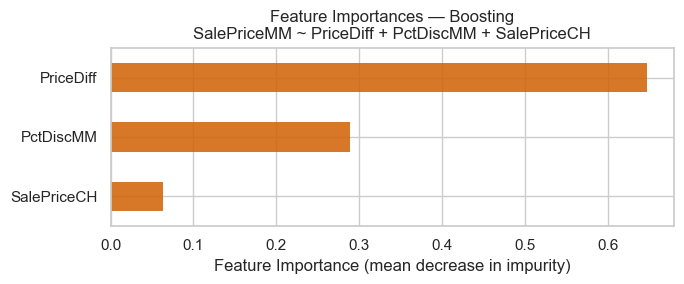

Feature importances (sorted descending):
PriceDiff      0.647801
PctDiscMM      0.289488
SalePriceCH    0.062711


In [8]:
plot_feature_importance(
    boo, FEATURES,
    title='Feature Importances — Boosting\nSalePriceMM ~ PriceDiff + PctDiscMM + SalePriceCH',
    color=SAFFRON)

## Predict on Test Dataset

Mirrors R: `b <- predict(boo, test)`

In [9]:
# Predict — mirrors R: b <- predict(boo, test)
b = boo.predict(X_test)

print(f'Predictions shape: {b.shape}')
print(f'First 5: {b[:5].round(4)}')

Predictions shape: (321,)
First 5: [2.0039 1.794  2.1283 2.097  2.1758]


## Plot: Predictions vs. Actuals

Mirrors R:
```r
b_df %>% ggplot(aes(x=SalePriceMM, y=b)) +
  geom_point() + geom_smooth(method='lm', col='red', se=FALSE)
```

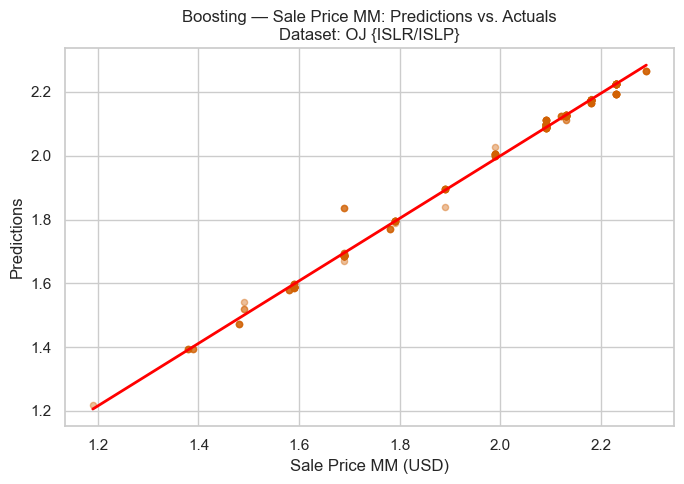

In [10]:
plot_predictions(y_test.values, b,
                 title='Boosting — Sale Price MM: Predictions vs. Actuals',
                 color=SAFFRON)

## Performance: RMSE and R²

Mirrors R:
```r
sqrt(mean((test$SalePriceMM - b)^2))   # RMSE
cor(test$SalePriceMM, b)^2             # R-squared
```

In [11]:
rmse_boo = root_mean_squared_error(y_test, b)
r2_boo   = r2_score(y_test, b)

print('Boosting — Performance on Test Set')
print(f'  RMSE : {rmse_boo:.6f}')
print(f'  R²   : {r2_boo:.6f}')

Boosting — Performance on Test Set
  RMSE : 0.018310
  R²   : 0.994724


---

# Hyperparameter Tuning: GridSearchCV

The R script uses a single fixed `tuneGrid`. Here we extend that by sweeping
key hyperparameters via `GridSearchCV` — a natural Python enhancement.

We tune `n_estimators`, `max_depth`, and `learning_rate` while keeping
other parameters at their R-equivalent values.

In [12]:
# Grid search — extends R's single tuneGrid to a sweep
param_grid = {
    'n_estimators' : [100, 300, 500],
    'max_depth'    : [2, 3, 4],
    'learning_rate': [0.05, 0.1, 0.2],
}

boo_base = GradientBoostingRegressor(
    subsample=1.0,
    max_features=1.0,
    min_samples_leaf=1,
    random_state=1234
)

grid_search = GridSearchCV(boo_base,
                            param_grid,
                            cv=RepeatedKFold(n_splits=5, n_repeats=2,
                                             random_state=1234),
                            scoring='neg_root_mean_squared_error',
                            n_jobs=-1,
                            verbose=0)
grid_search.fit(X_train, y_train)

print('GridSearchCV — Best Parameters')
print(f'  {grid_search.best_params_}')
print(f'  Best CV RMSE: {-grid_search.best_score_:.6f}')

GridSearchCV — Best Parameters
  {'learning_rate': 0.2, 'max_depth': 2, 'n_estimators': 500}
  Best CV RMSE: 0.005519


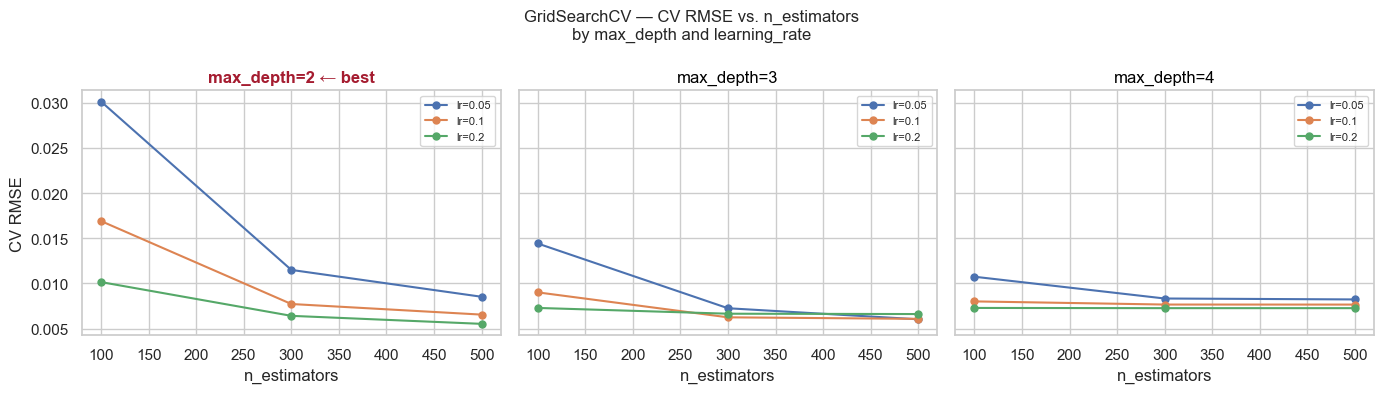

In [13]:
# Visualize grid search results — learning_rate vs. n_estimators at best max_depth
results = pd.DataFrame(grid_search.cv_results_)
best_depth = grid_search.best_params_['max_depth']

fig, axes = plt.subplots(1, len(param_grid['max_depth']), figsize=(14, 4), sharey=True)

for i, depth in enumerate(param_grid['max_depth']):
    mask = results['param_max_depth'] == depth
    sub  = results[mask].copy()
    sub['RMSE'] = -sub['mean_test_score']

    for lr in param_grid['learning_rate']:
        lr_mask = sub['param_learning_rate'] == lr
        axes[i].plot(
            sub[lr_mask]['param_n_estimators'].astype(int),
            sub[lr_mask]['RMSE'],
            'o-', linewidth=1.5, markersize=5,
            label=f'lr={lr}'
        )
    border = CRIMSON if depth == best_depth else 'black'
    axes[i].set_title(f'max_depth={depth}'
                      + (' ← best' if depth == best_depth else ''),
                      color=border, fontweight='bold' if depth == best_depth else 'normal')
    axes[i].set_xlabel('n_estimators')
    if i == 0:
        axes[i].set_ylabel('CV RMSE')
    axes[i].legend(fontsize=8)

fig.suptitle('GridSearchCV — CV RMSE vs. n_estimators\nby max_depth and learning_rate',
             fontsize=12)
plt.tight_layout()
plt.show()

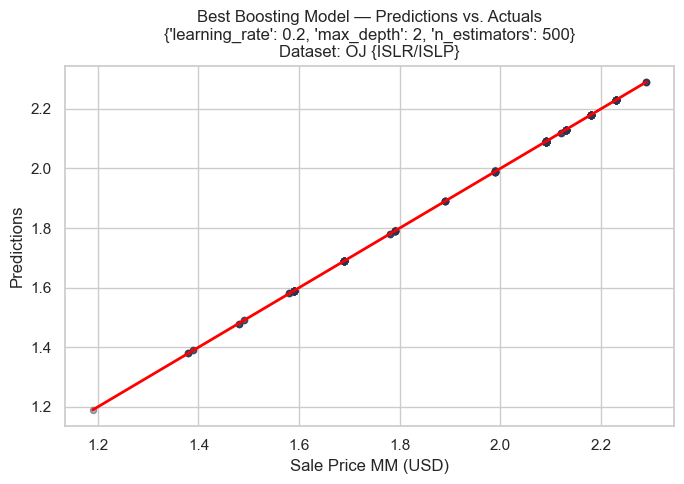

Best model — Test RMSE: 0.000467   R²: 0.999997


In [14]:
# Best model predictions
b_best     = grid_search.predict(X_test)
rmse_best  = root_mean_squared_error(y_test, b_best)
r2_best    = r2_score(y_test, b_best)

plot_predictions(y_test.values, b_best,
                 title=f'Best Boosting Model — Predictions vs. Actuals\n'
                       f'{grid_search.best_params_}',
                 color=INDIGO)

print(f'Best model — Test RMSE: {rmse_best:.6f}   R²: {r2_best:.6f}')

---

# Learning Curves — Staged Predictions

One advantage of `GradientBoostingRegressor` over the R xgbTree call:
we can inspect the **staged predictions** — how train and test RMSE
evolve as trees are added. This is equivalent to what XGBoost's
`eval_metric` watchlist provides, and mirrors the spirit of R's
`plot(boo)` learning curve.

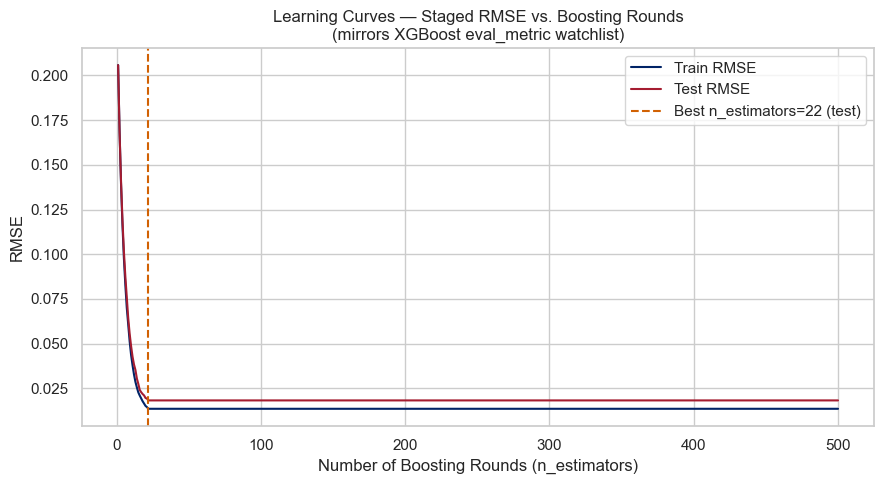

Min test RMSE at n_estimators=22: 0.018310


In [15]:
# Staged predictions — train and test RMSE at each boosting round
train_errors = []
test_errors  = []

for y_train_pred, y_test_pred in zip(
        boo.staged_predict(X_train),
        boo.staged_predict(X_test)):
    train_errors.append(root_mean_squared_error(y_train, y_train_pred))
    test_errors.append(root_mean_squared_error(y_test,  y_test_pred))

n_trees = np.arange(1, len(train_errors) + 1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(n_trees, train_errors, color=ROYALBLUE, linewidth=1.5, label='Train RMSE')
ax.plot(n_trees, test_errors,  color=CRIMSON,   linewidth=1.5, label='Test RMSE')

# Mark the minimum test RMSE
best_n = int(np.argmin(test_errors)) + 1
ax.axvline(best_n, color=SAFFRON, linestyle='--', linewidth=1.5,
           label=f'Best n_estimators={best_n} (test)')

ax.set_xlabel('Number of Boosting Rounds (n_estimators)')
ax.set_ylabel('RMSE')
ax.set_title('Learning Curves — Staged RMSE vs. Boosting Rounds\n'
             '(mirrors XGBoost eval_metric watchlist)')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Min test RMSE at n_estimators={best_n}: {min(test_errors):.6f}')

---

# Summary and Conclusions

## Model Comparison

In [16]:
comparison = pd.DataFrame([
    {'Model'      : 'Boosting — fixed params (R mirror)',
     'Predictors' : str(FEATURES),
     'CV RMSE'    : cv_rmse.mean(),
     'Test RMSE'  : rmse_boo,
     'Test R²'    : r2_boo},
    {'Model'      : f'Boosting — GridSearchCV best {grid_search.best_params_}',
     'Predictors' : str(FEATURES),
     'CV RMSE'    : -grid_search.best_score_,
     'Test RMSE'  : rmse_best,
     'Test R²'    : r2_best},
])

print('Model Comparison — Boosting Regression (SalePriceMM)')
print(comparison[['Model', 'CV RMSE', 'Test RMSE', 'Test R²']]
      .to_string(index=False, float_format='{:.6f}'.format))

Model Comparison — Boosting Regression (SalePriceMM)
                                                                                   Model  CV RMSE  Test RMSE  Test R²
                                                      Boosting — fixed params (R mirror) 0.018800   0.018310 0.994724
Boosting — GridSearchCV best {'learning_rate': 0.2, 'max_depth': 2, 'n_estimators': 500} 0.005519   0.000467 0.999997


## Key Takeaways

1. **Different predictors from notebook #5:** The RF notebook excluded `PriceDiff`
   deliberately; this boosting notebook includes it — and `PriceDiff` dominates
   feature importance. This illustrates how predictor selection affects the
   problem difficulty and model behavior.

2. **Boosting vs. Random Forest:** Boosting builds trees sequentially, each
   correcting residuals of the previous. RF builds trees in parallel with
   random feature subsets. Boosting often achieves lower bias at the cost
   of higher sensitivity to hyperparameters.

3. **Staged predictions (learning curve):** A unique advantage of
   `GradientBoostingRegressor` — inspecting RMSE at each round shows
   where test error starts to plateau or increase, guiding `n_estimators`
   selection without a full grid search.

4. **Gamma / min_impurity_decrease:** The `gamma=2.1` in xgbTree controls
   minimum loss reduction for a split in XGBoost's units. sklearn's
   `min_impurity_decrease` operates on a different scale — the mapping
   is approximate. For exact xgbTree equivalence, use the `xgboost` package
   directly (`pip install xgboost`).

## R → Python Mapping

| R | Python |
|---|--------|
| `train(method='xgbTree')` | `GradientBoostingRegressor()` (or `xgboost.XGBRegressor`) |
| `nrounds=500` | `n_estimators=500` |
| `max_depth=3` | `max_depth=3` |
| `eta=0.2` | `learning_rate=0.2` |
| `gamma=2.1` | `min_impurity_decrease` (approximate) |
| `colsample_bytree=1` | `max_features=1.0` |
| `min_child_weight=1` | `min_samples_leaf=1` |
| `subsample=1` | `subsample=1.0` |
| `trainControl(repeatedcv, number=5, repeats=2)` | `RepeatedKFold(n_splits=5, n_repeats=2)` |
| `expand.grid(tuneGrid)` | `param_grid` dict + `GridSearchCV` |
| `varImp(boo)$importance` | `boo.feature_importances_` |
| `plot(varImp(boo))` | `plot_feature_importance()` helper |
| `predict(boo, test)` | `boo.predict(X_test)` |
| `sqrt(mean((y-b)^2))` | `root_mean_squared_error(y, b)` |
| `cor(y, b)^2` | `r2_score(y, b)` |
| *(not in R)* | `boo.staged_predict()` — learning curves |

## References

1. Harvard STAT 109, 2023. Weekly slides by Dr. Bharatendra Rai.
2. Dr. Bharatendra Rai. YouTube channel. https://youtu.be/cW59Yh_GfNk
3. John Maindonald and W. John Braun. *Data Analysis and Graphics Using R*. Cambridge. Third Ed. ISBN 978-0-521-76293-9.
4. Gareth James, et al. *An Introduction to Statistical Learning with Applications in R*. Springer. ISBN 978-1-4614-7137-0.
5. James, G., Witten, D., Hastie, T., Tibshirani, R., Taylor, J. *An Introduction to Statistical Learning with Applications in Python*. Springer, 2023. https://www.statlearning.com